<a href="https://colab.research.google.com/github/karakotiharshitawork/CODSOFT/blob/main/Pneumonia_Detection_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
import os
print(os.listdir())


['.config', 'sample_data']


In [8]:
!pip install kaggle


In [9]:
import os

os.environ['KAGGLE_USERNAME'] = 'harshitakarakoti'
os.environ['KAGGLE_KEY'] = 'KGAT_4be835279d5ac7c29b32b9b3f75f05e5'

In [10]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:59<00:00, 41.4MB/s]



In [11]:
import zipfile

zip_ref = zipfile.ZipFile('chest-xray-pneumonia.zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from sklearn.metrics import classification_report, confusion_matrix

In [13]:
train_path = '/content/chest_xray/train'
test_path = '/content/chest_xray/test'
val_path = '/content/chest_xray/val'

print("Paths set successfully!")

Paths set successfully!


In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 646ms/step - accuracy: 0.8321 - loss: 0.4409 - val_accuracy: 0.6875 - val_loss: 0.8552
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.8932 - loss: 0.2530 - val_accuracy: 0.7500 - val_loss: 0.5089
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9149 - loss: 0.2114 - val_accuracy: 0.7500 - val_loss: 0.5184
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9174 - loss: 0.1977 - val_accuracy: 0.6875 - val_loss: 0.6597
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9245 - loss: 0.1886 - val_accuracy: 0.7500 - val_loss: 0.5103


In [18]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

advanced_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

advanced_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

advanced_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
advanced_history = advanced_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 725ms/step - accuracy: 0.8581 - loss: 0.3122 - val_accuracy: 0.6875 - val_loss: 0.5191
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 626ms/step - accuracy: 0.9245 - loss: 0.1864 - val_accuracy: 0.7500 - val_loss: 0.3917
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 629ms/step - accuracy: 0.9316 - loss: 0.1685 - val_accuracy: 0.7500 - val_loss: 0.4305
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 626ms/step - accuracy: 0.9369 - loss: 0.1569 - val_accuracy: 0.7500 - val_loss: 0.4382
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.9390 - loss: 0.1537 - val_accuracy: 0.6875 - val_loss: 0.5846


In [20]:
predictions = advanced_model.predict(test_data)
predictions = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, predictions))

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 502ms/step
              precision    recall  f1-score   support

           0       0.96      0.65      0.77       234
           1       0.82      0.98      0.89       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624



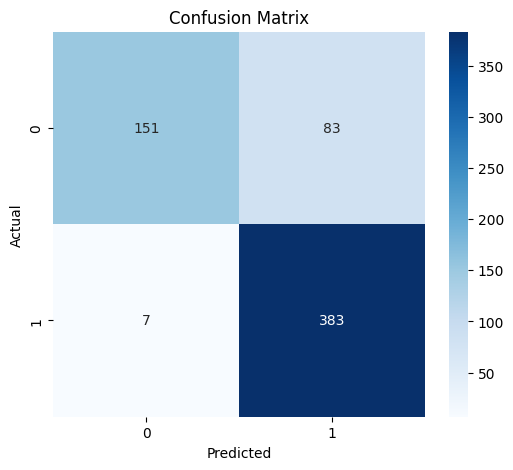

In [21]:
cm = confusion_matrix(test_data.classes, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
advanced_model.save("pneumonia_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [23]:
pneumonia_model.h5

NameError: name 'pneumonia_model' is not defined

In [24]:
advanced_model.save("pneumonia_model.h5")

print("Model saved successfully!")

Model saved successfully!


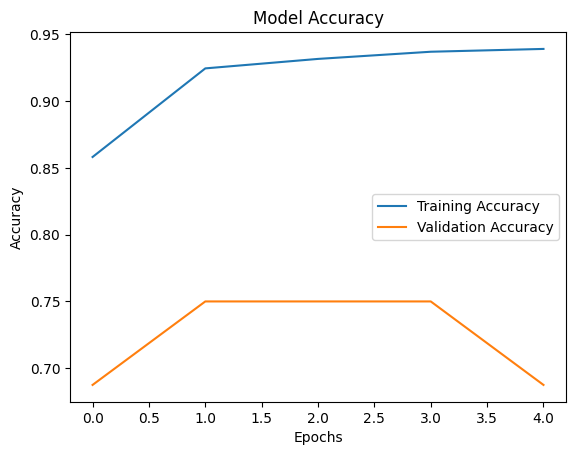

In [25]:
plt.plot(advanced_history.history['accuracy'], label='Training Accuracy')
plt.plot(advanced_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

In [26]:
from tensorflow.keras.preprocessing import image

In [ ]:
from google.colab import files
files.upload()

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='.jpg,.png', multiple=False)
display(uploader)

FileUpload(value={}, accept='.jpg,.png', description='Upload')

In [37]:
import io
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np

file_name = list(uploader.value.keys())[0]
content = uploader.value[file_name]['content']

img = Image.open(io.BytesIO(content)).resize((224,224))
img = np.array(img) / 255.0
img = np.expand_dims(img, axis=0)

print("Image loaded successfully")

Image loaded successfully


In [39]:
import io
import numpy as np
from PIL import Image

file_name = list(uploader.value.keys())[0]
content = uploader.value[file_name]['content']

img = Image.open(io.BytesIO(content)).convert('RGB')
img = img.resize((224, 224))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Ready for model prediction")

Ready for model prediction


In [42]:
from tensorflow.keras.models import load_model

model = load_model("pneumonia_model.h5")

In [43]:
import os
os.listdir()

['.config',
 'chest_xray',
 'drive',
 'pneumonia_model.h5',
 'chest-xray-pneumonia.zip',
 'sample_data']

In [44]:
from tensorflow.keras.models import load_model

model = load_model("pneumonia_model.h5")
print("Model loaded successfully")

Model loaded successfully


In [45]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
[[0.26957297]]


In [46]:
if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
else:
    print("NORMAL")

NORMAL


In [47]:
import os

train_dir = "chest_xray/train"

print("Train folder exists:", os.path.exists(train_dir))
print("Classes:", os.listdir(train_dir))

Train folder exists: True
Classes: ['PNEUMONIA', 'NORMAL']


In [48]:
import os

train_dir = "chest_xray/train"

pneumonia_count = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))
normal_count = len(os.listdir(os.path.join(train_dir, "NORMAL")))

print("PNEUMONIA images:", pneumonia_count)
print("NORMAL images:", normal_count)

PNEUMONIA images: 3875
NORMAL images: 1341


In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [50]:
train_data = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [51]:
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
history = baseline_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 806ms/step - accuracy: 0.8127 - loss: 0.4193 - val_accuracy: 0.7388 - val_loss: 0.6342
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 699ms/step - accuracy: 0.9013 - loss: 0.2322 - val_accuracy: 0.7019 - val_loss: 0.7291
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 694ms/step - accuracy: 0.9168 - loss: 0.2067 - val_accuracy: 0.8782 - val_loss: 0.3070
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 691ms/step - accuracy: 0.9325 - loss: 0.1754 - val_accuracy: 0.8782 - val_loss: 0.3494
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 720ms/step - accuracy: 0.9247 - loss: 0.1808 - val_accuracy: 0.8093 - val_loss: 0.4258


In [54]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [55]:
base_model.trainable = False

In [56]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [57]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
history_tl = transfer_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 862ms/step - accuracy: 0.8472 - loss: 0.3382 - val_accuracy: 0.8446 - val_loss: 0.3537
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 760ms/step - accuracy: 0.9156 - loss: 0.2138 - val_accuracy: 0.8734 - val_loss: 0.3053
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 778ms/step - accuracy: 0.9245 - loss: 0.1869 - val_accuracy: 0.8750 - val_loss: 0.3112
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 749ms/step - accuracy: 0.9275 - loss: 0.1793 - val_accuracy: 0.8862 - val_loss: 0.2802
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 752ms/step - accuracy: 0.9379 - loss: 0.1599 - val_accuracy: 0.8958 - val_loss: 0.2656


In [59]:
import numpy as np

y_true = test_data.classes
y_pred = transfer_model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 327ms/step


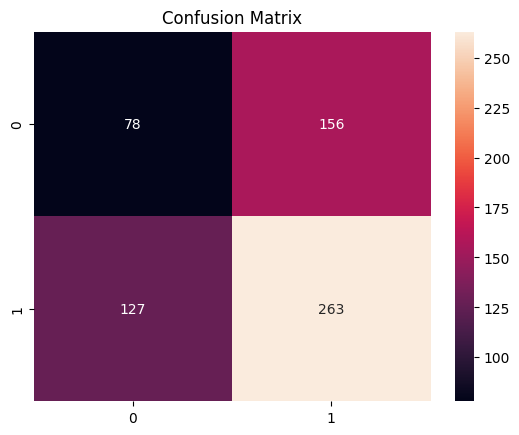

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.33      0.36       234
           1       0.63      0.67      0.65       390

    accuracy                           0.55       624
   macro avg       0.50      0.50      0.50       624
weighted avg       0.53      0.55      0.54       624



In [62]:
print("Baseline CNN accuracy:", baseline_model.evaluate(test_data)[1])
print("VGG16 accuracy:", transfer_model.evaluate(test_data)[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 403ms/step - accuracy: 0.8093 - loss: 0.4258
Baseline CNN accuracy: 0.8092948794364929
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.8958 - loss: 0.2656
VGG16 accuracy: 0.8958333134651184
